In [4]:
import pandas as pd
drivers = pd.read_csv("../data/drivers.csv")
drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [5]:
# what is the shape of the dataset
drivers.shape

(861, 9)

In [6]:
# what are all the column names
drivers.columns

Index(['driverId', 'driverRef', 'number', 'code', 'forename', 'surname', 'dob',
       'nationality', 'url'],
      dtype='str')

In [7]:
# What data type is each column?
drivers.info()

<class 'pandas.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   driverId     861 non-null    int64
 1   driverRef    861 non-null    str  
 2   number       861 non-null    str  
 3   code         861 non-null    str  
 4   forename     861 non-null    str  
 5   surname      861 non-null    str  
 6   dob          861 non-null    str  
 7   nationality  861 non-null    str  
 8   url          861 non-null    str  
dtypes: int64(1), str(8)
memory usage: 60.7 KB


In [8]:
# Missing Values
drivers.isnull().sum()

driverId       0
driverRef      0
number         0
code           0
forename       0
surname        0
dob            0
nationality    0
url            0
dtype: int64

In [9]:
# interperting the missing values
#drivers[['number','code']].sample(10)
#drivers['code'].value_counts().head()
(drivers['code'] == '\\N').sum()

np.int64(757)

In [10]:
results = pd.read_csv("../data/results.csv")
results.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [11]:
results.shape

(26759, 18)

In [12]:
results.columns

Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype='str')

In [13]:
race_win = results.iloc[:,[1,2,3,6,7,8,9,14]]
race_win

,raceId,driverId,constructorId,position,positionText,positionOrder,points,rank
0,18,1,1,1,1,1,10.0,2
1,18,2,2,2,2,2,8.0,3
2,18,3,3,3,3,3,6.0,5
3,18,4,4,4,4,4,5.0,7
4,18,5,1,5,5,5,4.0,1
...,...,...,...,...,...,...,...,...
26754,1144,825,210,16,16,16,0.0,1
26755,1144,859,215,17,17,17,0.0,12
26756,1144,822,15,\N,R,18,0.0,19
26757,1144,861,3,\N,R,19,0.0,17


In [14]:
race_win['positionOrder'] == 1

0         True
1        False
2        False
3        False
4        False
         ...  
26754    False
26755    False
26756    False
26757    False
26758    False
Name: positionOrder, Length: 26759, dtype: bool

In [15]:
winners = race_win[race_win['positionOrder'] == 1]
winners

,raceId,driverId,constructorId,position,positionText,positionOrder,points,rank
0,18,1,1,1,1,1,10.0,2
22,19,8,6,1,1,1,10.0,2
44,20,13,6,1,1,1,10.0,3
66,21,8,6,1,1,1,10.0,1
88,22,13,6,1,1,1,10.0,3
...,...,...,...,...,...,...,...,...
26659,1140,832,6,1,1,1,25.0,7
26679,1141,830,9,1,1,1,26.0,1
26699,1142,847,131,1,1,1,25.0,4
26719,1143,830,9,1,1,1,25.0,2


In [16]:
winners['driverId'].value_counts()


driverId
1      105
30      91
830     63
20      53
117     51
      ... 
786      1
593      1
813      1
842      1
839      1
Name: count, Length: 115, dtype: int64

In [17]:
winner = winners['driverId'].value_counts().to_frame()
winner

,count
driverId,
1,105
30,91
830,63
20,53
117,51
...,...
786,1
593,1
813,1


In [18]:
# cheking the answer before merging
# winner['raceId'].nunique()
#type(winners['driverId'].value_counts()) or type(winner)
#type(winners)
#winner.columns
#winner.index
#new_winner.columns
#new_winner.index

In [19]:
new_winner = winner.rename(columns ={'count':'wins'} )
new_winner

,wins
driverId,
1,105
30,91
830,63
20,53
117,51
...,...
786,1
593,1
813,1


In [20]:
races = results.groupby('driverId').size().reset_index(name='races')
races

,driverId,races
0,1,356
1,2,184
2,3,206
3,4,404
4,5,112
...,...,...
856,858,36
857,859,11
858,860,3
859,861,9


In [21]:
wins_df = new_winner.reset_index('driverId')
wins_df

,driverId,wins
0,1,105
1,30,91
2,830,63
3,20,53
4,117,51
...,...,...
110,786,1
111,593,1
112,813,1
113,842,1


In [22]:
driver_stats = wins_df.merge(races, on= 'driverId', how='left')
driver_stats

,driverId,wins,races
0,1,105,356
1,30,91,308
2,830,63,209
3,20,53,300
4,117,51,202
...,...,...,...
110,786,1,8
111,593,1,10
112,813,1,96
113,842,1,154


In [23]:
driver_stats.merge(drivers, on= 'driverId')

,driverId,wins,races,driverRef,number,code,forename,surname,dob,nationality,url
0,1,105,356,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,30,91,308,michael_schumacher,\N,MSC,Michael,Schumacher,1969-01-03,German,http://en.wikipedia.org/wiki/Michael_Schumacher
2,830,63,209,max_verstappen,33,VER,Max,Verstappen,1997-09-30,Dutch,http://en.wikipedia.org/wiki/Max_Verstappen
3,20,53,300,vettel,5,VET,Sebastian,Vettel,1987-07-03,German,http://en.wikipedia.org/wiki/Sebastian_Vettel
4,117,51,202,prost,\N,\N,Alain,Prost,1955-02-24,French,http://en.wikipedia.org/wiki/Alain_Prost
...,...,...,...,...,...,...,...,...,...,...,...
110,786,1,8,fagioli,\N,\N,Luigi,Fagioli,1898-06-09,Italian,http://en.wikipedia.org/wiki/Luigi_Fagioli
111,593,1,10,parsons,\N,\N,Johnnie,Parsons,1918-07-04,American,http://en.wikipedia.org/wiki/Johnnie_Parsons
112,813,1,96,maldonado,13,MAL,Pastor,Maldonado,1985-03-09,Venezuelan,http://en.wikipedia.org/wiki/Pastor_Maldonado
113,842,1,154,gasly,10,GAS,Pierre,Gasly,1996-02-07,French,http://en.wikipedia.org/wiki/Pierre_Gasly


In [24]:
board = driver_stats.merge(drivers, on= 'driverId')[
    ['forename', 'surname', 'wins', 'races', 'dob', 'nationality']
]
board

,forename,surname,wins,races,dob,nationality
0,Lewis,Hamilton,105,356,1985-01-07,British
1,Michael,Schumacher,91,308,1969-01-03,German
2,Max,Verstappen,63,209,1997-09-30,Dutch
3,Sebastian,Vettel,53,300,1987-07-03,German
4,Alain,Prost,51,202,1955-02-24,French
...,...,...,...,...,...,...
110,Luigi,Fagioli,1,8,1898-06-09,Italian
111,Johnnie,Parsons,1,10,1918-07-04,American
112,Pastor,Maldonado,1,96,1985-03-09,Venezuelan
113,Pierre,Gasly,1,154,1996-02-07,French


In [25]:
board['full_name'] = (
    board['forename'] + ' ' + board['surname']
)
leaderboard = board[['full_name', 'wins', 'races']].head(10)
leaderboard

,full_name,wins,races
0,Lewis Hamilton,105,356
1,Michael Schumacher,91,308
2,Max Verstappen,63,209
3,Sebastian Vettel,53,300
4,Alain Prost,51,202
5,Ayrton Senna,41,162
6,Fernando Alonso,32,404
7,Nigel Mansell,31,192
8,Jackie Stewart,27,100
9,Niki Lauda,25,174


In [26]:
leaderboard['Rank'] = range(1,11)
leaderboard['win_rate'] = leaderboard['wins'] / leaderboard['races']
Leaderboard = leaderboard[['Rank','full_name','wins','races','win_rate']].sort_values('wins',ascending=False)
Leaderboard.style.hide(axis="index")

Rank,full_name,wins,races,win_rate
1,Lewis Hamilton,105,356,0.294944
2,Michael Schumacher,91,308,0.295455
3,Max Verstappen,63,209,0.301435
4,Sebastian Vettel,53,300,0.176667
5,Alain Prost,51,202,0.252475
6,Ayrton Senna,41,162,0.253086
7,Fernando Alonso,32,404,0.079208
8,Nigel Mansell,31,192,0.161458
9,Jackie Stewart,27,100,0.270000
10,Niki Lauda,25,174,0.143678


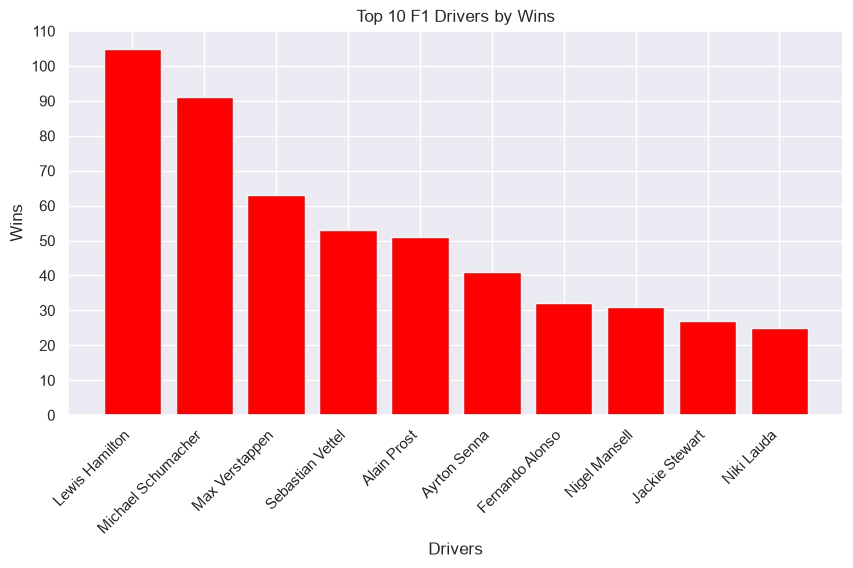

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(Leaderboard['full_name'], Leaderboard['wins'], color='red')
plt.yticks(range(0, max(Leaderboard['wins']) + 10, 10))
plt.xticks(rotation=45, ha= 'right')
plt.ylabel("Wins")
plt.xlabel("Drivers")
plt.title("Top 10 F1 Drivers by Wins")
plt.savefig(
    "../images/top10_wins.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


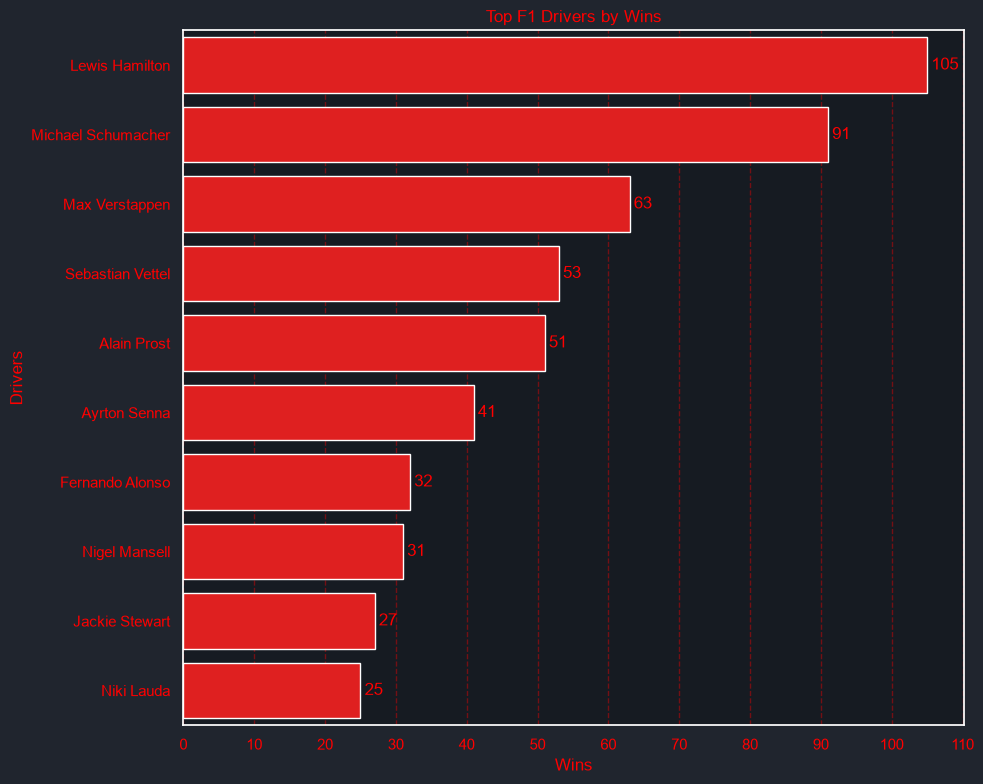

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,8), facecolor="#20252e")
ax = sns.barplot(
    data=Leaderboard,
    y='full_name',
    x='wins',
    color='red'
)
ax.set_facecolor("#161b22")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3,color='red')
plt.xticks(range(0, max(Leaderboard['wins'] + 10), 10), color='red')
plt.yticks(color='red')
plt.ylabel("Drivers", color='red')
plt.xlabel("Wins", color='red')
plt.title("Top F1 Drivers by Wins", color='red')
plt.grid(axis='x', linestyle='--', alpha=0.4, color='red')
plt.tight_layout()
plt.savefig(
    "../images/top10_wins(seaborn).png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [29]:
winrate_df = Leaderboard.sort_values('win_rate', ascending=False)
winrate_df['win_rate_pct'] = winrate_df['win_rate'] * 100
winrate_df

,Rank,full_name,wins,races,win_rate,win_rate_pct
2,3,Max Verstappen,63,209,0.301435,30.143541
1,2,Michael Schumacher,91,308,0.295455,29.545455
0,1,Lewis Hamilton,105,356,0.294944,29.494382
8,9,Jackie Stewart,27,100,0.270000,27.000000
5,6,Ayrton Senna,41,162,0.253086,25.308642
4,5,Alain Prost,51,202,0.252475,25.247525
3,4,Sebastian Vettel,53,300,0.176667,17.666667
7,8,Nigel Mansell,31,192,0.161458,16.145833
9,10,Niki Lauda,25,174,0.143678,14.367816
6,7,Fernando Alonso,32,404,0.079208,7.920792


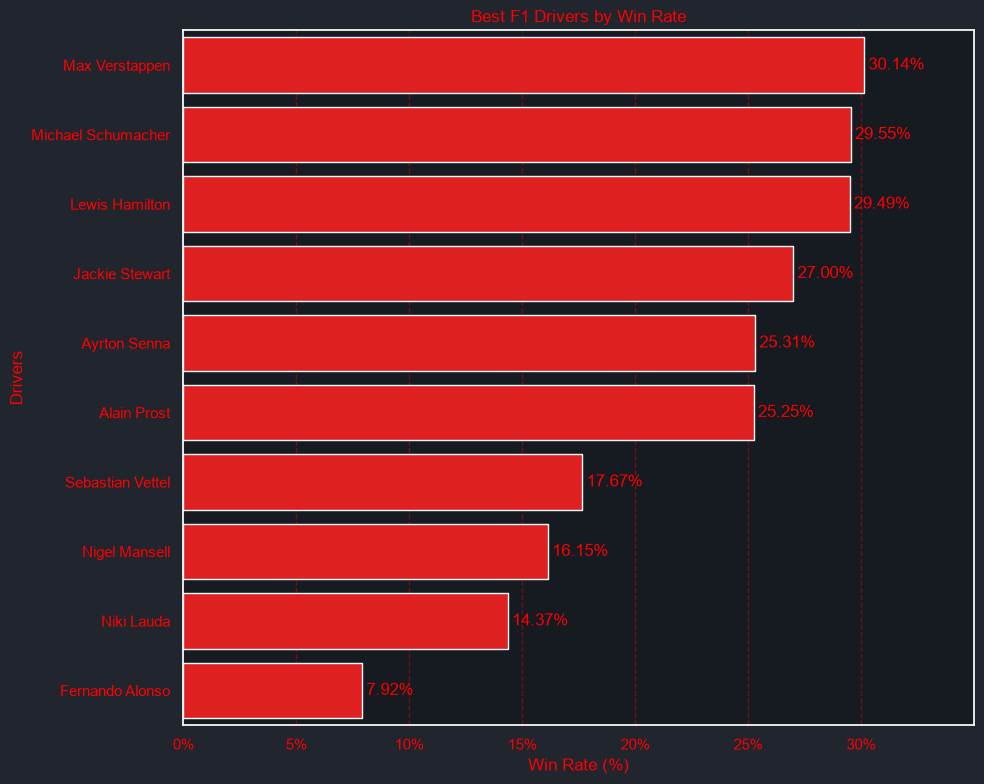

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
plt.figure(figsize=(10,8), facecolor="#20252e")
ax = sns.barplot(
    data=winrate_df,
    y='full_name',
    x='win_rate_pct',
    color='red'
)
ax.set_facecolor("#161b22")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3,color='red')
ticks = range(0, int(winrate_df['win_rate_pct'].max()) + 5, 5)
plt.xticks(
    ticks,
    [f"{t}%" for t in ticks],
    color='red'
)
plt.xlim(0, 35)
plt.yticks(color='red')
plt.ylabel("Drivers", color='red')
plt.xlabel("Win Rate (%)", color='red')
plt.title("Best F1 Drivers by Win Rate", color='red')
plt.grid(axis='x', linestyle='--', alpha=0.4, color='red')
plt.tight_layout()
plt.savefig(
    "../images/best_drivers_winrate.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


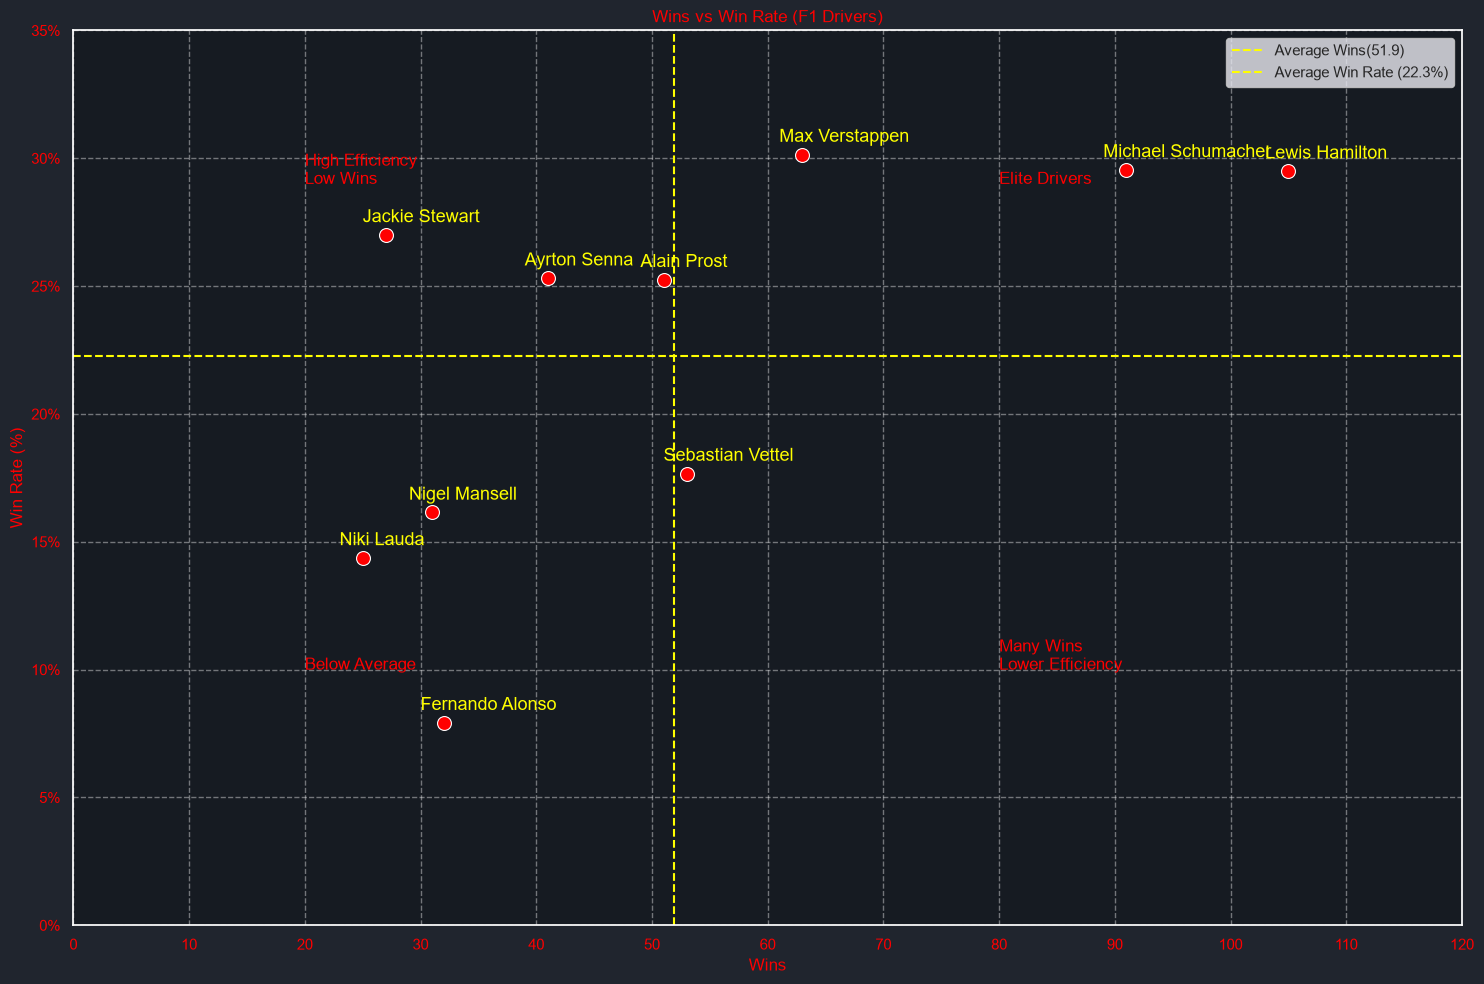

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="darkgrid")
plt.figure(figsize=(15,10), facecolor="#20252e")
ax = sns.scatterplot(
    data=winrate_df,
    x='wins',
    y='win_rate_pct',
    color='red',
    s=100
)
ax.set_facecolor("#161b22")
avg_wins = winrate_df['wins'].mean()
avg_winrate = winrate_df['win_rate_pct'].mean()
plt.axvline(
    avg_wins,
    color='yellow',
    linestyle='--',
    label=f'Average Wins({avg_wins:.1f})'
)
plt.axhline(
    avg_winrate,
    color='yellow',
    linestyle='--', 
    label=f'Average Win Rate ({avg_winrate:.1f}%)'
)
for _, row in winrate_df.iterrows():
    plt.text(
        row['wins']-2,
        row['win_rate_pct']+0.5,
        row['full_name'],
        fontsize=13,
        color='yellow'
    )
plt.legend()
plt.xticks(range(0,121,10), color='red')
ticks = range(0,36,5)
plt.yticks(
    ticks,
    [f"{t}%" for t in ticks],
    color='red'
)
plt.xlabel("Wins", color='red')
plt.ylabel("Win Rate (%)", color='red')
plt.title("Wins vs Win Rate (F1 Drivers)", color='red')
plt.grid(True, linestyle='--', alpha=0.4, color='white')
plt.text(80, 29, "Elite Drivers", color='red')
plt.text(20, 29, "High Efficiency\nLow Wins", color='red')
plt.text(80, 10, "Many Wins\nLower Efficiency", color='red')
plt.text(20, 10, "Below Average", color='red')
plt.tight_layout()
plt.savefig(
    "../images/win_vs_winrate.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()